# Introduction to control theory. 

## TP5. State Observers. LQ.
## Study load

Course grade breakdown:

    Labs - 40%
    
    Final project presentation 30%

    Final test 30%
    
File name for lab submission: yourname_labnumber.ipynb (example: elenavanneaux_TP4.ipynb)    

The completed notebook should be **submitted via the corresponding Moodle assignment before the beginning of the next session.**

## Prerequisites for practice
### Math
During the course, we will cover the following areas of mathematics:
    
    1. Linear Algebra

    2. Calculus

    3. Differential equations

    4. Dynamics (Mechanics and Physics)

### Python programming
In the labs we will use a Python programming language and the following libraries:

    1. NumPy https://numpy.org/doc/stable/

    2. SciPy https://docs.scipy.org/doc/scipy/

    3. Matplotlib https://matplotlib.org/stable/tutorials/index

    4. SymPy https://docs.sympy.org/latest/tutorials/intro-tutorial/intro.html

    5. Control System Library https://python-control.readthedocs.io/en/0.10.1/intro.html

### Jupyter Notebook Markdown Cells Documentation

Please check on Markdown cells documentation, to provide a fancy look for your notebooks!

https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html



# Ex1: Designing a dynamic output-feedback controller for a cart-pole

## TODO

Consider the cart-pole system from TP4.  There, you designed a full-state feedback controller $u=-Kx, $ which stabilizes the system in steady state
$x = (0,0,0,0).$

0. If you have not done this - do it today! And don't hesitate to ask questions if it is unclear.

This time let us assume that we only measure the position and the angular velocity, while their derivatives are not availabe. I.e. $y_{output} = (y, \theta)' = Cx,$ where 
$$C = \begin{pmatrix} 1 & 0 & 0 &0 \\ 0 & 0 & 1 &0 \end{pmatrix}$$

1. Is the pair of matrices (A,C) observable? Why is this important? 

2. For an autonomous system
$$
\dot x = Ax, \ y = Cx
$$

design an observer $$\dot{\hat{x}} = (A - LC)\hat{x} + Ly,$$ such that the estimation of the state $\hat{x}$ converges to real state $x$. To do that, we need to find a matrice $L$ such that the matrice $A-LC$ is Hurwitz (i.e., all its eigenvalues have a negative real part). 

**Remark:** to place arbitary eigenvalues $\lambda_1,\ldots \lambda_n$ in matrice (A - LC) with matrice L, it is the same as to place $\lambda_1,\ldots \lambda_n$ in matrice $(A^T - C^TL^T)$ with matrice $L^T$. 

Plot a real trajectory $x$ starting from the point $x_0 = (2,0,1,0)$ and its estimation $\hat{x}$ starting from the point $\hat{x}_0 = (3,-1,2,0.5)$ to show convergence.

3. Design an optimal estimator and an optimal estimated-state-feedback controller (both via LQR design as discussed in the lecture), which stabilizes the system in (0,0,0,0).

**Remark:** See slide "observer and controller" in the lecture.

## System status modified from TP4

In [24]:
import numpy as np
import sympy as sp
from scipy.integrate import solve_ivp
from scipy import signal
from scipy.linalg import solve_continuous_are
import matplotlib.pyplot as plt
import control as ctr

M, m, b, l, I, g, F = sp.symbols('M m b l I g F')
y, y1, theta, theta1, doty1, dottheta1 = sp.symbols('y y1 theta theta1 doty1 dottheta1')

eq1 = (M+m)*doty1 + b*y1 + m*l*dottheta1*sp.cos(theta) - m*l*theta1**2*sp.sin(theta) - F
eq2 = m*l*sp.cos(theta)*doty1 + (I+m*l**2)*dottheta1 - m*g*l*sp.sin(theta)

dottheta1_sol = sp.solve(eq2, dottheta1)[0]
doty1_sol = sp.simplify(sp.solve(eq1.subs(dottheta1, dottheta1_sol), doty1)[0])
dottheta1_sol = sp.simplify(dottheta1_sol.subs(doty1, doty1_sol))

f = sp.Matrix([y1, doty1_sol, theta1, dottheta1_sol])
jacobian_A = sp.simplify(f.jacobian(sp.Matrix([y, y1, theta, theta1])).subs([(theta, 0), (theta1, 0)]))
jacobian_B = sp.simplify(f.jacobian(sp.Matrix([F])).subs([(theta, 0), (theta1, 0)]))

params = {M: 2.5, m: 0.2, b: 0.1, l: 0.7, I: 0.006, g: 9.81}
A = np.array(jacobian_A.subs(params).evalf()).astype(float)
B = np.array(jacobian_B.subs(params).evalf()).astype(float).reshape(4, 1)
C = np.array([[1, 0, 0, 0],
              [0, 0, 1, 0]])


## Ex1.1 Is (A,C) observable? 

In [25]:
O = np.vstack([C, C@A, C@A@A, C@A@A@A])
rank = np.linalg.matrix_rank(O)
print(f"Observability matrix rank: {rank}, system dimension: 4")
print("(A, C) is observable." if rank == 4 else "(A, C) is Not observable.")

Observability matrix rank: 4, system dimension: 4
(A, C) is observable.


The observability matrix $\mathcal{O} = [C;, CA;, CA^2;, CA^3]$ has rank 4, which equals the system dimension $n=4$. Therefore, the pair $(A, C)$ is observable

This is important because observability guarantees that it is theoretically possible to reconstruct the full state vector $x$ from the partial output $y = Cx$. In our case we only measure position $y$ and angle $\theta$, but their derivatives are not directly available. Since the system is observable, we can design a state observer to accurately estimate all four states, which is required for state-feedback control

## Ex 1.2 plot X (4 channels, convergence)

Observer gain L:
 [[15.2589361  -0.95090756]
 [57.13273115 -7.82986312]
 [-0.9041673  14.70124766]
 [-6.36581927 67.40545536]]
Eigenvalues of A-LC: [-5.99999999 -9.         -7.         -8.        ]


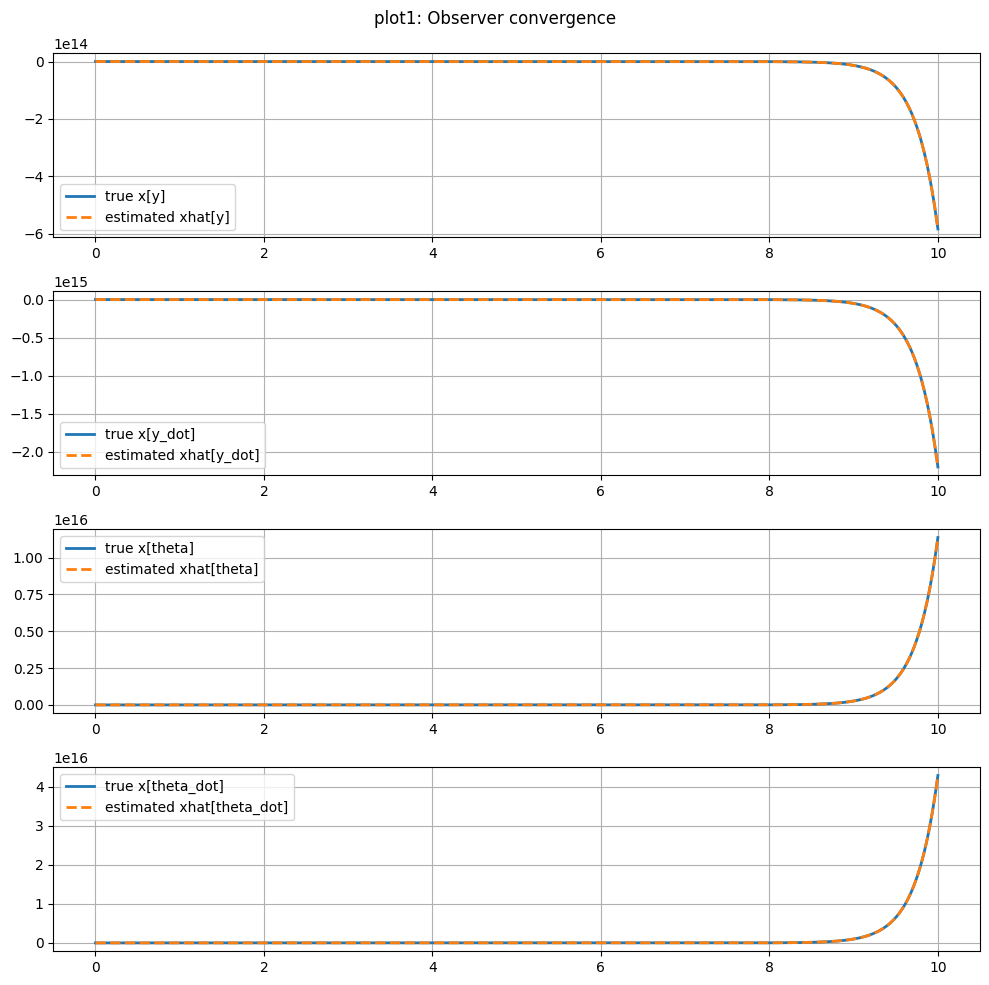

In [26]:
desired_poles_obs = [-6, -7, -8, -9]
result = signal.place_poles(A.T, C.T, desired_poles_obs)
L = result.gain_matrix.T
print("Observer gain L:\n", L)
print("Eigenvalues of A-LC:", np.linalg.eigvals(A - L @ C))

x0    = np.array([2, 0, 1, 0])
xhat0 = np.array([3, -1, 2, 0.5])

def autonomous_with_observer(t, state):
    x, xhat = state[:4], state[4:]
    dx    = A @ x
    dxhat = (A - L @ C) @ xhat + L @ (C @ x)
    return np.concatenate([dx, dxhat])

sol = solve_ivp(autonomous_with_observer, (0, 10),
                np.concatenate([x0, xhat0]),
                t_eval=np.linspace(0, 10, 1000))

labels = ['y', 'y_dot', 'theta', 'theta_dot']
fig, axes = plt.subplots(4, 1, figsize=(10, 10))
for i in range(4):
    axes[i].plot(sol.t, sol.y[i],    label=f'true x[{labels[i]}]', linewidth=2)
    axes[i].plot(sol.t, sol.y[i+4], '--', label=f'estimated xhat[{labels[i]}]', linewidth=2)
    axes[i].legend(); axes[i].grid(True)
plt.suptitle('plot1: Observer convergence')
plt.tight_layout(); plt.show()


To design the observer $\dot{\hat{x}} = (A - LC)\hat{x} + Ly$, we need to choose $L$ such that all eigenvalues of $(A - LC)$ have strictly negative real parts (Hurwitz condition).

Following the remark, we use the transpose trick: placing eigenvalues in $(A^T - C^T L^T)$ with matrix $L^T$ is equivalent to placing them in $(A - LC)$ with $L$. We apply scipy.signal.place_poles on the transposed system and choose observer poles ${-6, -7, -8, -9}$, which are faster than the controller poles to ensure the estimation error decays quickly.

The resulting $(A - LC)$ is Hurwitz, as confirmed by its eigenvalues. The plots show that starting from different initial conditions ($x_0 = (2,0,1,0)$ and $\hat{x}_0 = (3,-1,2,0.5)$), the estimation $\hat{x}$ converges to the true trajectory $x$, confirming that the observer works correctly.

## Ex 1.3 

In [27]:
#optimal LQR
Q_ctrl = np.diag([1, 1, 10, 1])
R_ctrl = np.array([[0.1]])
P_ctrl = solve_continuous_are(A, B, Q_ctrl, R_ctrl)
K = np.linalg.inv(R_ctrl) @ B.T @ P_ctrl
print("Optimal controller gain K:\n", K)
print("Closed-loop eigenvalues (A-BK):", np.linalg.eigvals(A - B @ K))

Q_est = np.eye(4)
R_est = np.eye(2) * 0.01
P_est = solve_continuous_are(A.T, C.T, Q_est, R_est)
L_opt = P_est @ C.T @ np.linalg.inv(R_est)
print("\nOptimal observer gain L:\n", L_opt)
print("Closed-loop eigenvalues (A-LC):", np.linalg.eigvals(A - L_opt @ C))

Optimal controller gain K:
 [[ -3.16227766  -7.07727056 -86.47150293 -23.33306147]]
Closed-loop eigenvalues (A-BK): [-4.45070991+0.j         -3.44171698+0.j         -0.91786096+0.49295565j
 -0.91786096-0.49295565j]

Optimal observer gain L:
 [[10.91763768 -0.04525855]
 [ 9.5984304  -0.92595969]
 [-0.04525855 12.77115674]
 [-0.14616074 31.55224642]]
Closed-loop eigenvalues (A-LC): [ -9.94831749 -11.22570498  -1.00658516  -1.54800301]


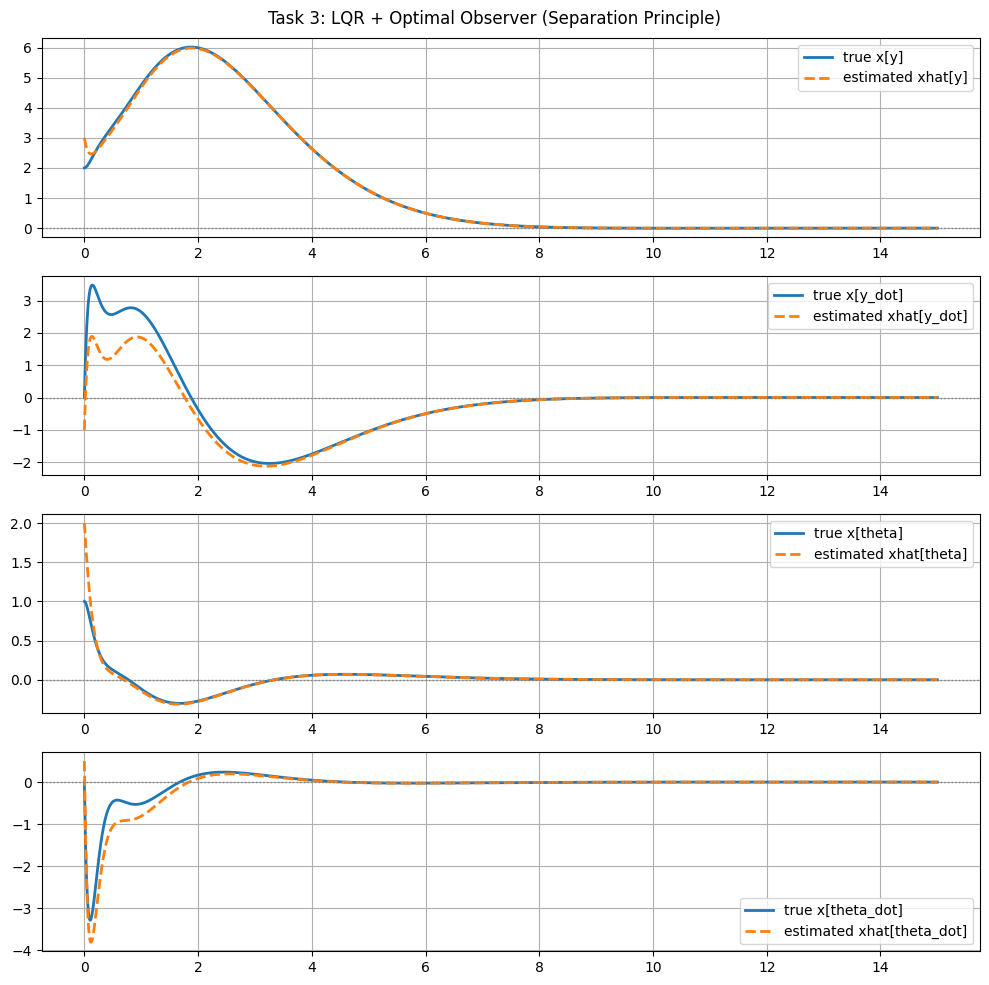

In [28]:
# kalman observer
def closed_loop_ode(t, state):
    x, xhat = state[:4], state[4:]
    u     = -K @ xhat
    dx    = A @ x + B @ u
    dxhat = (A - L_opt @ C) @ xhat + B @ u + L_opt @ (C @ x)
    return np.concatenate([dx, dxhat])

sol2 = solve_ivp(closed_loop_ode, (0, 15),
                 np.concatenate([x0, xhat0]),
                 t_eval=np.linspace(0, 15, 1500))

fig, axes = plt.subplots(4, 1, figsize=(10, 10))
for i in range(4):
    axes[i].plot(sol2.t, sol2.y[i],    label=f'true x[{labels[i]}]', linewidth=2)
    axes[i].plot(sol2.t, sol2.y[i+4], '--', label=f'estimated xhat[{labels[i]}]', linewidth=2)
    axes[i].axhline(0, color='gray', linestyle=':', linewidth=1)
    axes[i].legend(); axes[i].grid(True)
plt.suptitle('Task 3: LQR + Optimal Observer (Separation Principle)')
plt.tight_layout(); 
plt.show()

According to the Separation Principle, the optimal controller LQR and the optimal estimator Kalman Observer can be designed independently and then combined:Optimal control gain $K$: This is obtained by solving the Continuous Algebraic Riccati Equation. In the cost weight matrix $Q$, the diagonal weight for the angle $\theta$ is 10 to prioritize pendulum stability.

 $R$ is set to 0.1.Optimal observer gain $L_{opt}$: This is obtained by solving CARE based on the duality principle. It uses $Q_{est} = I_4$ for process noise and $R_{est} = 0.01 I_2$ for observation noise. 
 
 A small observation noise means we trust the sensors more. This smaller $R_{est}$ enables the observer to converge faster than the pole placement observer in Ex 1.2.Closed-loop control law: $u = -K\hat{x}$. This uses the estimated state instead of the true state.
 
 The graph shows that the estimated value $\hat{x}$ converges quickly to the true state $x$. The entire system also stabilizes at the origin $(0,0,0,0)$ under the controller.